Analyzing output of run such as:

```
python train.py --model GSPA --task localization --seed 0
```

In [74]:
import numpy as np
import json
import phate
import scprep
import scipy

In [18]:
seed = 0
save_as = 0
model = 'GSPA'

In [12]:
with open(f'results/{model}/{seed}_config.json') as f:
    config = json.load(f)
    
embedding = np.load(f'results/{model}/{save_as}_embedding.npy')
localization_score = np.load(f'results/{model}/{save_as}_localization.npy')
localization_truth = np.load('data/localization_signals.npz')['spread']

In [13]:
config

{'lr': 0.01,
 'dropout': 0.0,
 'epochs': 100,
 'weight_decay': 0.0,
 'patience': 50,
 'min_epochs': 50,
 'seed': 0,
 'walk_length': 80,
 'num_walks': 10,
 'task': 'localization',
 'model': 'GSPA',
 'dim': 16,
 'num_layers': 2,
 'bias': 1,
 'act': 'relu',
 'num_classes': 2,
 'attention': True,
 'val_prop': 0.05,
 'test_prop': 0.1,
 'split_seed': 1234,
 'save_as': '0'}

In [21]:
phate_op = phate.PHATE(random_state=seed, verbose=False)
data_phate = phate_op.fit_transform(embedding)

Calculating PHATE...
  Running PHATE on 250 observations and 16 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculating affinities...
  Calculated graph and diffusion operator in 0.01 seconds.
  Calculating optimal t...
    Automatically selected t = 14
  Calculated optimal t in 0.02 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...
  Calculated metric MDS in 0.06 seconds.
Calculated PHATE in 0.10 seconds.


<AxesSubplot:>

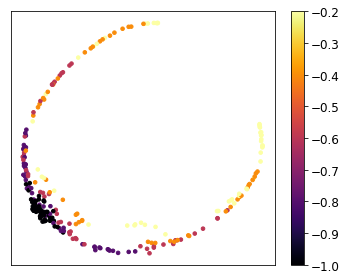

In [73]:
scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), c=-1*localization_truth)

<AxesSubplot:>

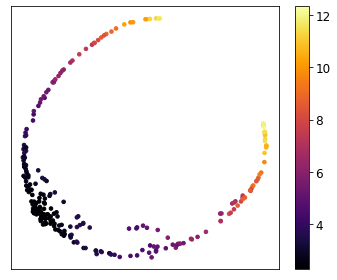

In [59]:
scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), c=localization_score[0])

In [76]:
scipy.stats.spearmanr(-1*localization_truth, localization_score[0]).statistic

0.8452962787548411